In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os
from utils import load_all_images

TOKENIZER_PATH = '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/OpenMAGViT2'
TOKENIZER = os.path.basename(TOKENIZER_PATH)
RECONSTRUCTION_PATH = f'/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{TOKENIZER}'

sys.path.append(TOKENIZER_PATH)
os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)

In [3]:
# Import everything from your evaluation file
from evaluation_original_reso import *
import matplotlib.pyplot as plt

/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Configuration
model_type = "Open-MAGVIT2"
original_reso = True
batch_size = 1
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

config_file = "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/OpenMAGViT2/configs/Open-MAGVIT2/gpu/pretrain_lfqgan_256_262144.yaml"  
ckpt_path = "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/OpenMAGViT2/upload_ckpts/Open-MAGVIT2/pretrain_256_262144/pretrain256_262144.ckpt"
image_folder = "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original"

In [5]:
# Load model
config_model = load_config(config_file, display=False)
model = load_vqgan_new(config_model, model_type, ckpt_path=ckpt_path).to(DEVICE)
print(f"Model device: {next(model.parameters()).device}")

/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from src/Open_MAGVIT2/modules/autoencoder/lpips/vgg.pth
Use the Discriminator without Bluring
VQLPIPSWithDiscriminator running with hinge loss.
Model device: cuda:0


In [6]:
# Load images
images, image_names, _ = load_all_images(image_folder)

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: physics1.png
Loaded: physics2.png


Input image shape: torch.Size([1, 3, 2100, 1400])
Encoded codes shape: torch.Size([11616])
Number of tokens: 11616
Original image pixels: 2940000
Compression ratio: 253.10x
Saved: graph_theory1_11616.png


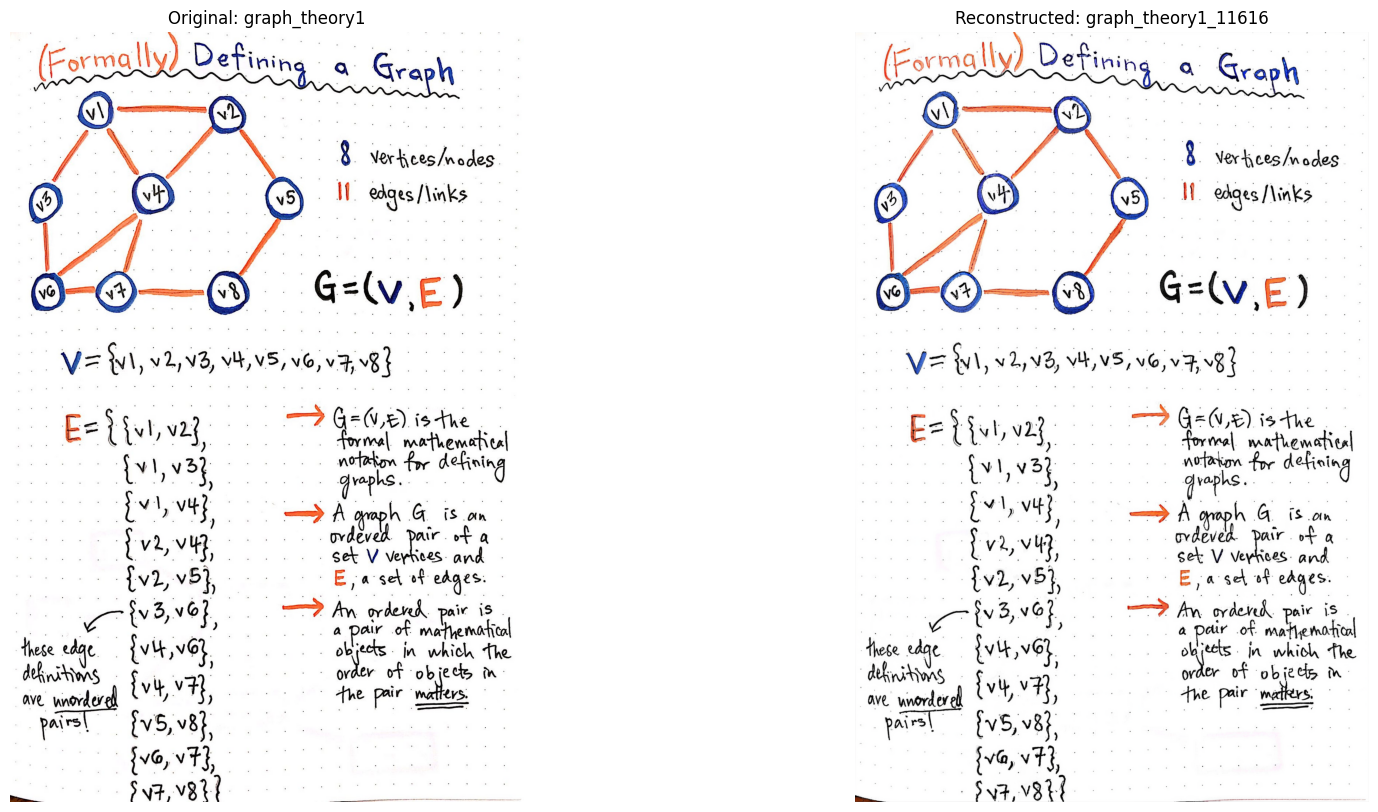

Input image shape: torch.Size([1, 3, 626, 712])
Encoded codes shape: torch.Size([1800])
Number of tokens: 1800
Original image pixels: 445712
Compression ratio: 247.62x
Saved: line_chart_1800.png


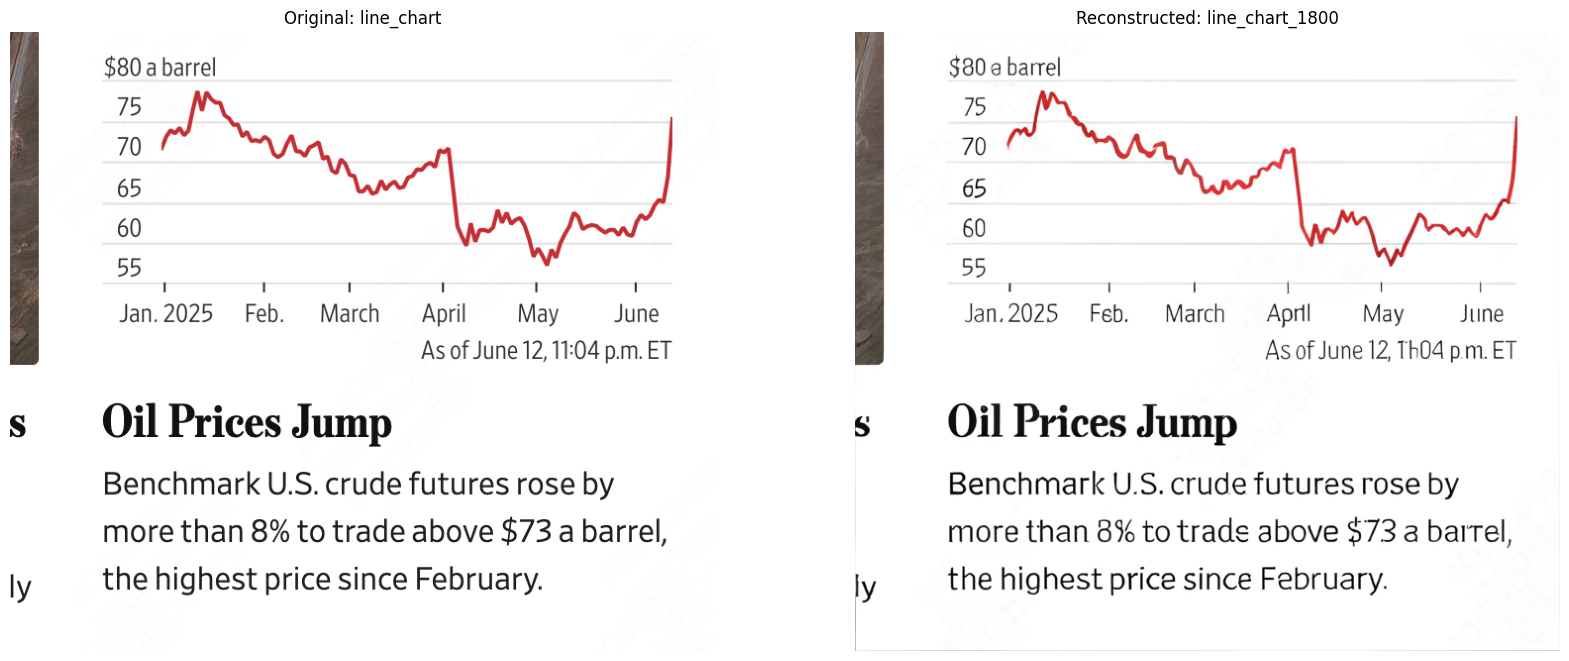

Input image shape: torch.Size([1, 3, 935, 800])
Encoded codes shape: torch.Size([2950])
Number of tokens: 2950
Original image pixels: 748000
Compression ratio: 253.56x
Saved: logo1_2950.png


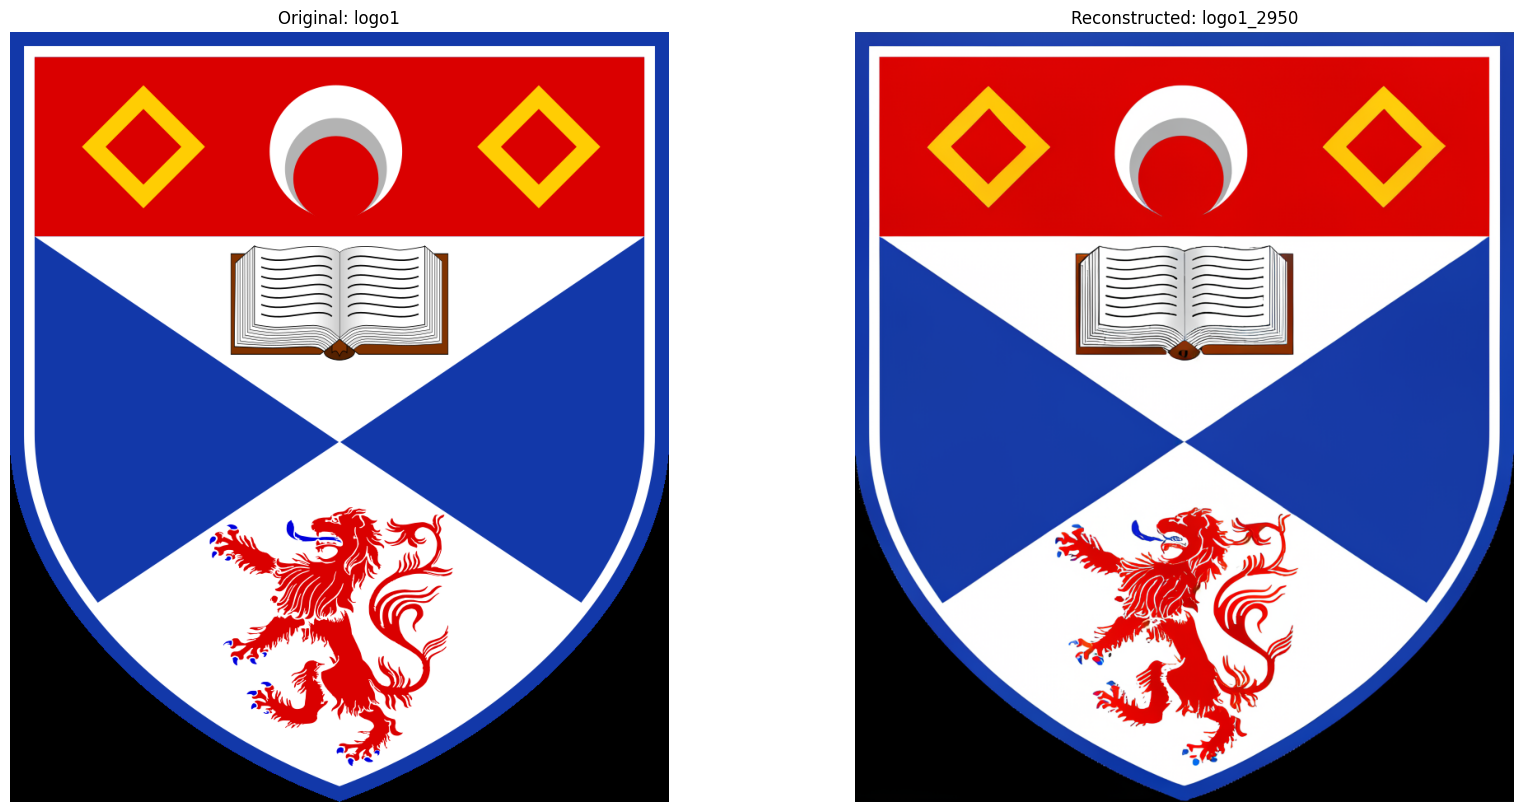

Input image shape: torch.Size([1, 3, 586, 555])
Encoded codes shape: torch.Size([1295])
Number of tokens: 1295
Original image pixels: 325230
Compression ratio: 251.14x
Saved: logo2_1295.png


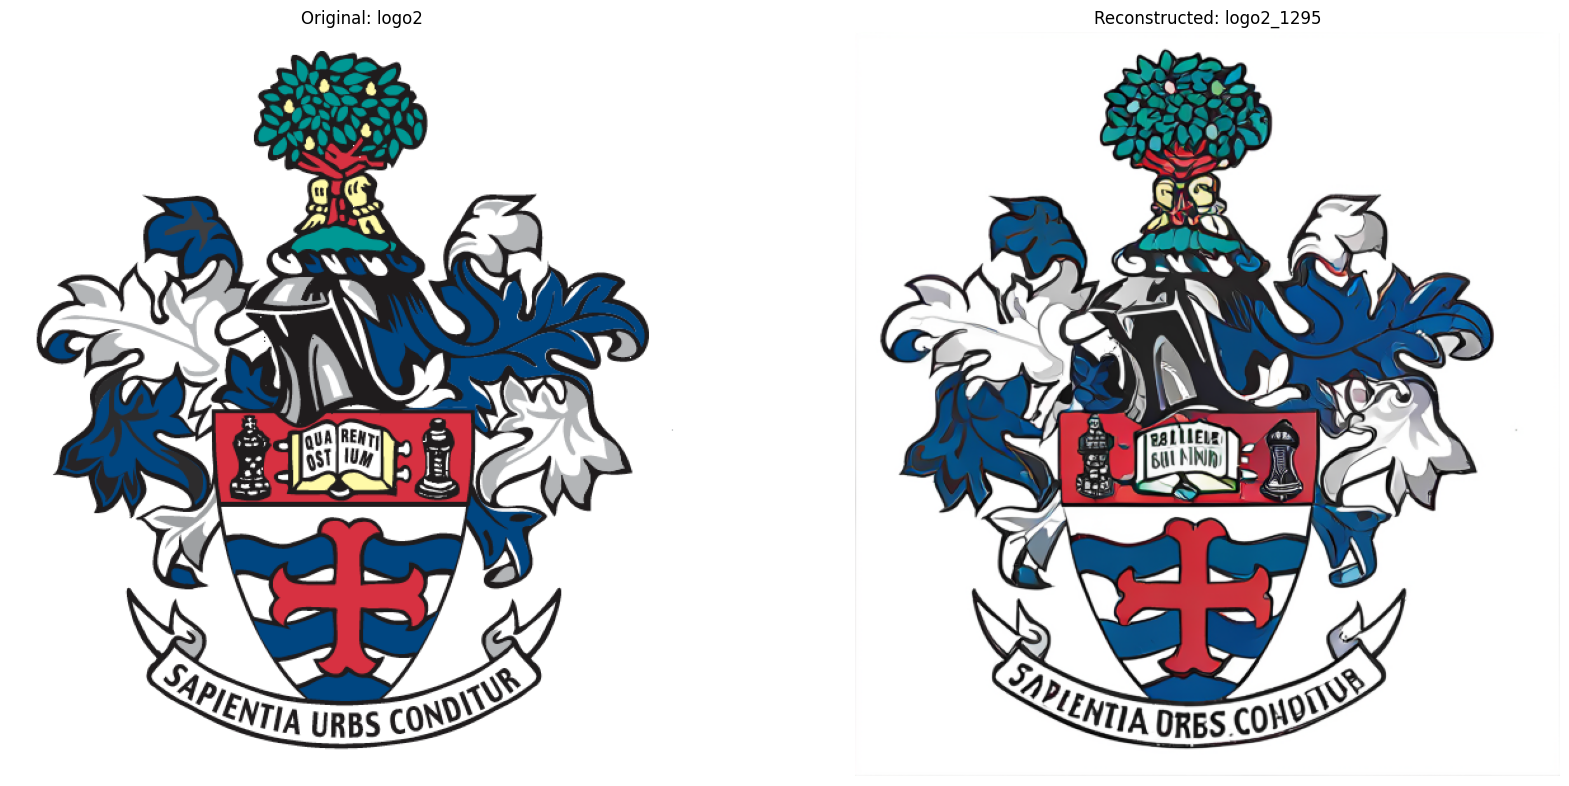

Input image shape: torch.Size([1, 3, 864, 934])
Encoded codes shape: torch.Size([3186])
Number of tokens: 3186
Original image pixels: 806976
Compression ratio: 253.29x
Saved: math_draft1_3186.png


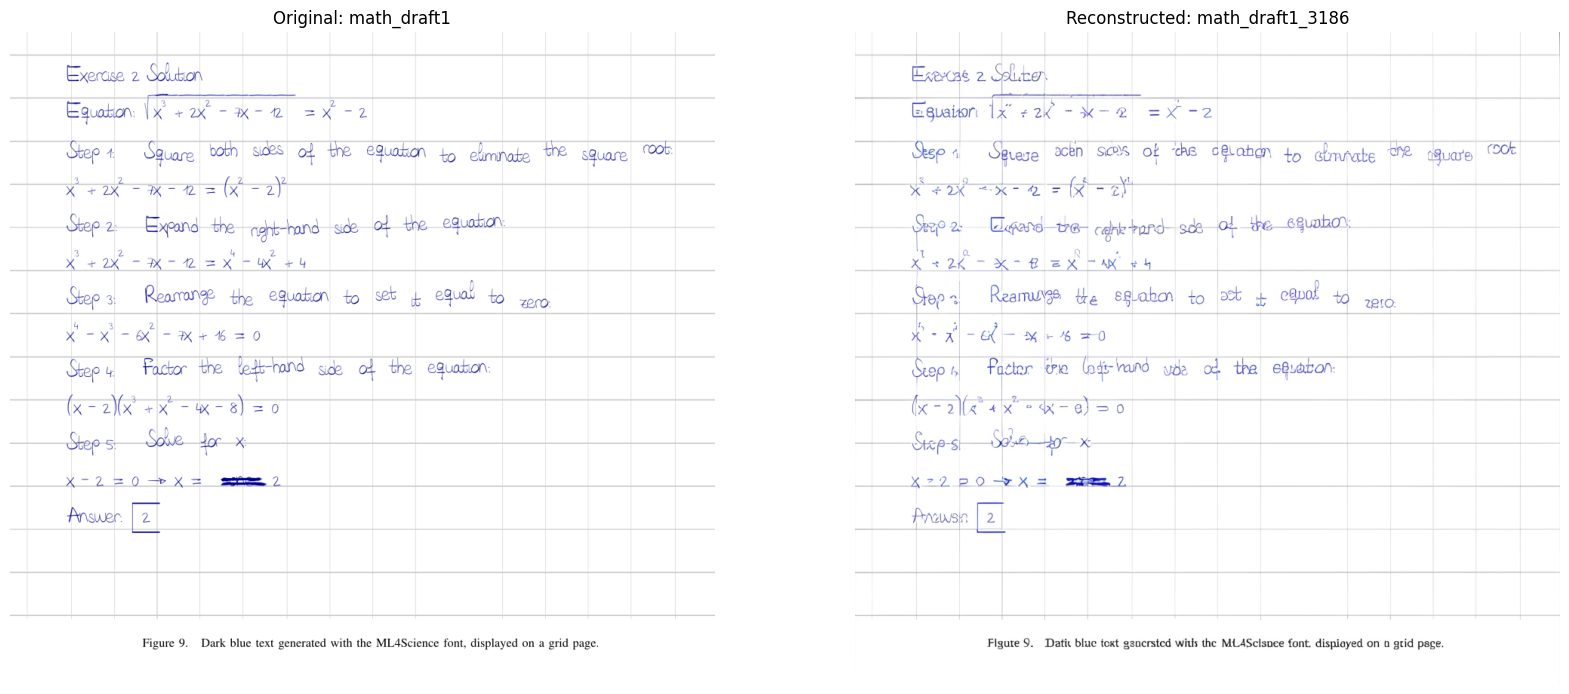

Input image shape: torch.Size([1, 3, 2048, 1536])
Encoded codes shape: torch.Size([12288])
Number of tokens: 12288
Original image pixels: 3145728
Compression ratio: 256.00x
Saved: menu_12288.png


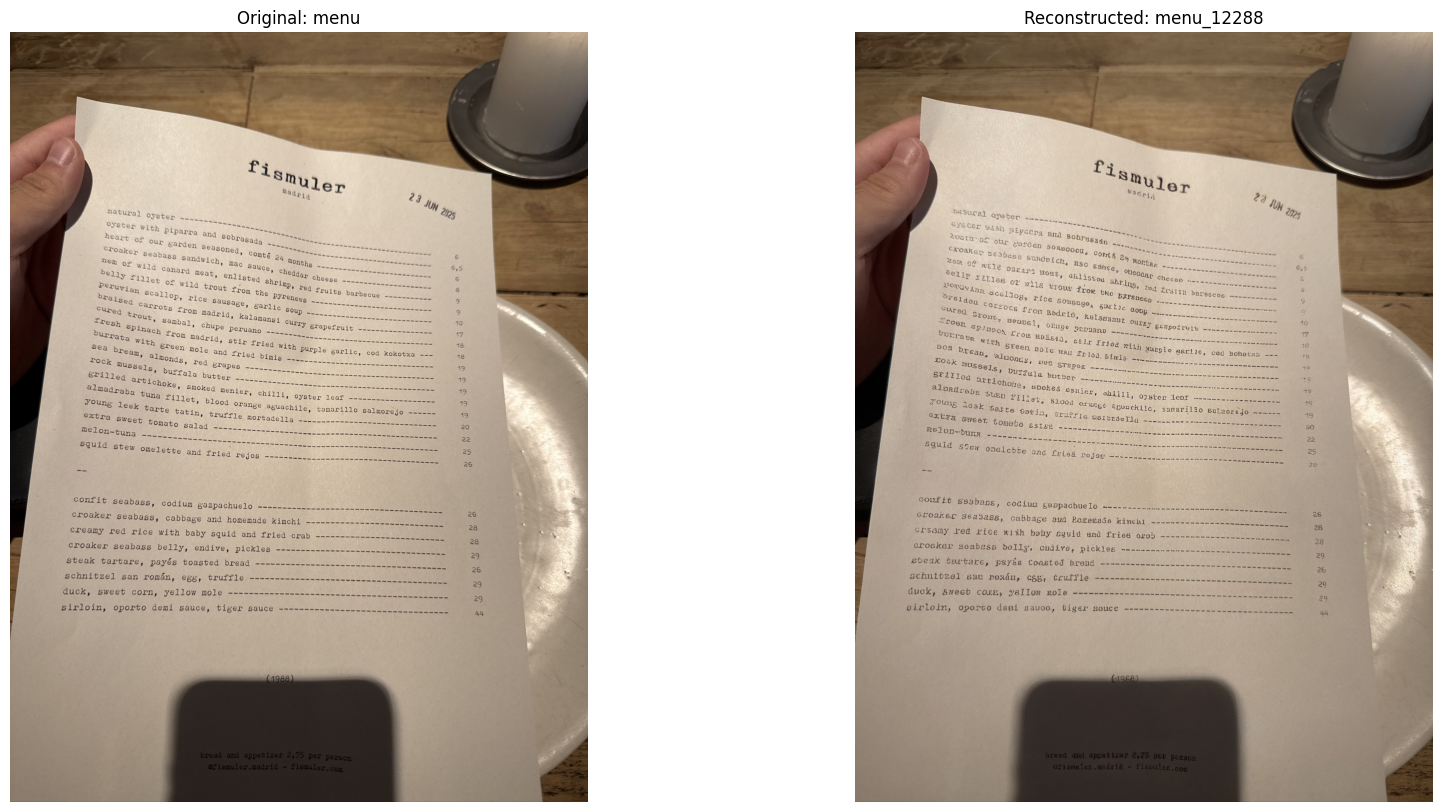

Input image shape: torch.Size([1, 3, 270, 527])
Encoded codes shape: torch.Size([561])
Number of tokens: 561
Original image pixels: 142290
Compression ratio: 253.64x
Saved: physics1_561.png


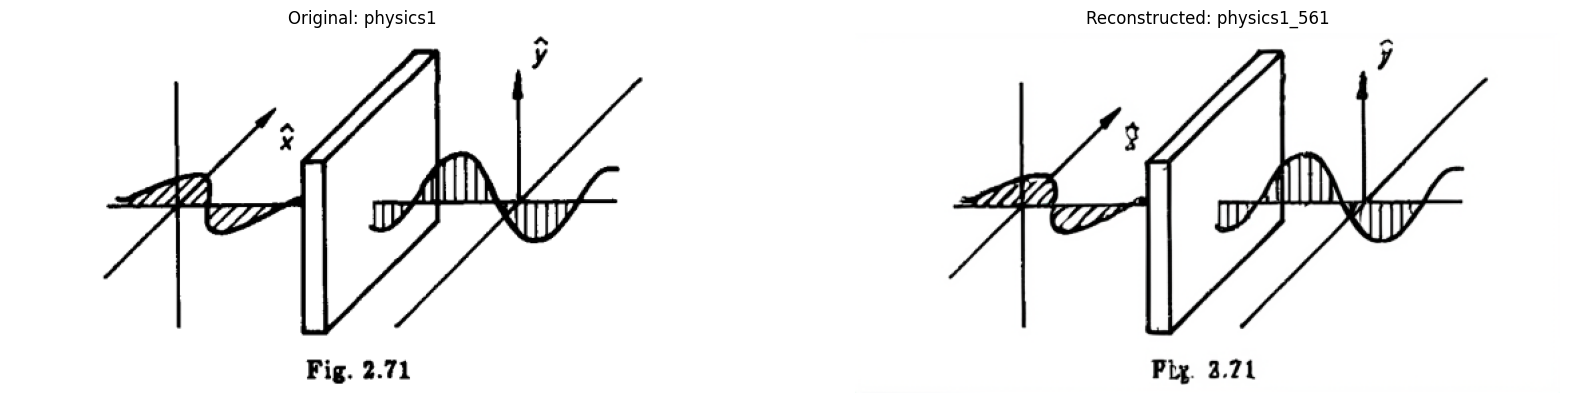

Input image shape: torch.Size([1, 3, 341, 651])
Encoded codes shape: torch.Size([902])
Number of tokens: 902
Original image pixels: 221991
Compression ratio: 246.11x
Saved: physics2_902.png


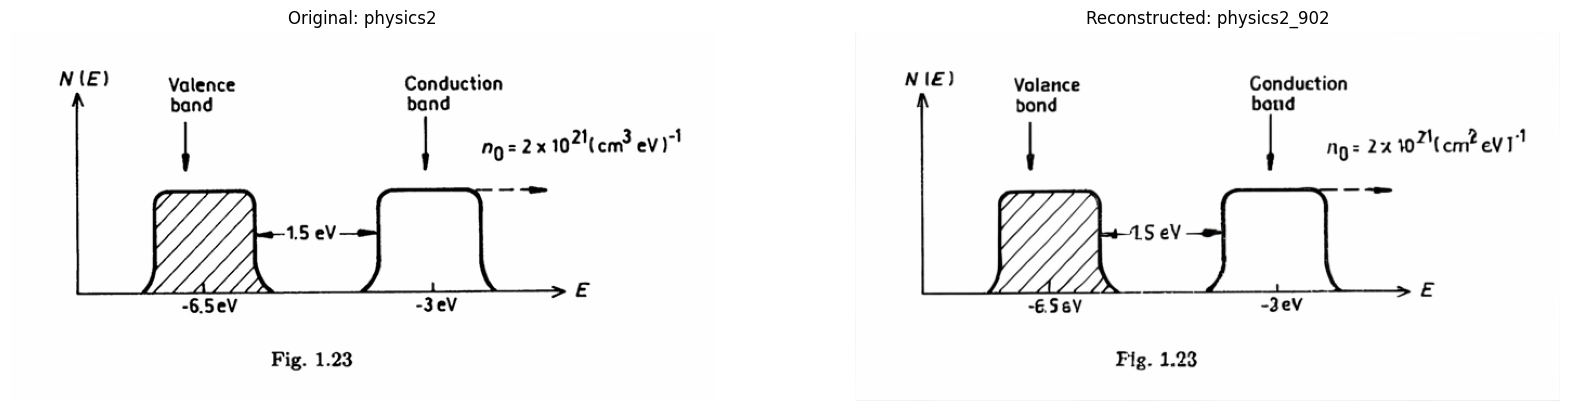

In [8]:
import os
from PIL import Image

# Create reconstruction directory if it doesn't exist
os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)

# Process each image
with torch.no_grad():
    for image, name in zip(images, image_names):
        # Convert to tensor (matching the exact preprocessing from ImagePaths)
        if not image.mode == "RGB":
            image = image.convert("RGB")
        
        # Convert to numpy and normalize exactly like in ImagePaths.preprocess_image
        image_np = np.array(image)
        image_np = (image_np/127.5 - 1.0).astype(np.float32)
        
        # Convert to tensor
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        print(f"Input image shape: {image_tensor.shape}")
        
        # Encode/decode (using your exact pipeline)
        images_padded, crop_region = pad_images(image_tensor)
        
        if model.use_ema:
            with model.ema_scope():
                quant, diff, indices, _ = model.encode(images_padded)
                reconstructed = model.decode(quant)
        else:
            quant, diff, indices, _ = model.encode(images_padded)
            reconstructed = model.decode(quant)
        
        print(f"Encoded codes shape: {indices.shape}")
        
        # Calculate tokens and compression ratio
        num_tokens = indices.numel()
        original_pixels = image_tensor.shape[-2] * image_tensor.shape[-1]
        compression_ratio = original_pixels / num_tokens
        
        print(f"Number of tokens: {num_tokens}")
        print(f"Original image pixels: {original_pixels}")
        print(f"Compression ratio: {compression_ratio:.2f}x")
        
        reconstructed = reconstructed.clamp(-1, 1)
        reconstructed = unpad_images(reconstructed, crop_region)
        
        # Convert to PIL for display and saving
        original_pil = custom_to_pil(image_tensor.squeeze(0).cpu())
        reconstructed_pil = custom_to_pil(reconstructed.squeeze(0).cpu())
        
        # Create filename with token count: image_name_token_number.png
        # Remove file extension from original name if present
        name_without_ext = os.path.splitext(name)[0]
        output_filename = f"{name_without_ext}_{num_tokens}.png"
        output_path = os.path.join(RECONSTRUCTION_PATH, output_filename)
        
        # Save the reconstructed image
        reconstructed_pil.save(output_path)
        print(f"Saved: {output_filename}")
        
        # Show results
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        ax1.imshow(original_pil)
        ax1.set_title(f"Original: {name}")
        ax1.axis('off')
        ax2.imshow(reconstructed_pil)
        ax2.set_title(f"Reconstructed: {name_without_ext}_{num_tokens}")
        ax2.axis('off')
        plt.show()